# FlexibleAlexNet on CIFAR-10 — JAX / Flax + Optuna HPO

A clean, modern reimplementation of AlexNet for CIFAR-10, extended into
**FlexibleAlexNet** — a fully parametric variant where the conv filter counts,
conv kernel sizes, and dense head (depth + width) are all tunable hyperparameters
searched jointly with learning rate, weight decay, and dropout via Optuna.

### What FlexibleAlexNet adds over the original
| Fixed in AlexNet | Tuneable in FlexibleAlexNet |
|---|---|
| Filter counts: `[64, 192, 384, 256, 256]` | `conv_width` ∈ {narrow, standard, wide} |
| All conv kernels: `3×3` | `kernel_size` ∈ {3, 5} — uniform across all blocks |
| 2 FC layers of width 2048 | `num_dense_layers` ∈ {1, 2, 3}, `dense_width` ∈ {512, 1024, 2048} |
| Fixed dropout 0.5 | `dropout_rate` ∈ [0.2, 0.6] |

### Architecture (parametric view)
```
Input  32×32×3
 │
 ├─ ConvBlock(conv_features[0], kernel_size) → BN → ReLU → MaxPool  → 15×15×F0
 ├─ ConvBlock(conv_features[1], kernel_size) → BN → ReLU → MaxPool  →  7×7×F1
 ├─ ConvBlock(conv_features[2], kernel_size) → BN → ReLU             →  7×7×F2
 ├─ ConvBlock(conv_features[3], kernel_size) → BN → ReLU             →  7×7×F3
 ├─ ConvBlock(conv_features[4], kernel_size) → BN → ReLU → MaxPool  →  3×3×F4
 │
 ├─ Flatten
 ├─ [Dense(dense_width) → ReLU → Dropout] × num_dense_layers
 └─ Dense(10) → logits
```

### Preset conv filter configs
| `conv_width` | F0 | F1 | F2 | F3 | F4 | Params (2-FC-1024 head) |
|---|---|---|---|---|---|---|
| `narrow` | 32 | 96 | 192 | 128 | 128 | ~2.5M |
| `standard` | 64 | 192 | 384 | 256 | 256 | ~8.5M |
| `wide` | 96 | 256 | 512 | 384 | 384 | ~18M |

### What we keep from the original paper (Krizhevsky et al., 2012)
- 5-conv-block → N-FC architecture
- Max-pooling after blocks 1, 2, and 5
- Overlapping pooling windows (3×3 stride 2)
- BatchNorm in place of LRN


## 1 · Install & verify JAX

In [ ]:
# Colab already ships JAX; pin compatible Flax + Optax + Optuna.
!pip install -q flax optax tensorflow-datasets optuna

import jax
print('JAX version :', jax.__version__)
print('Devices     :', jax.devices())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.8 MB/s eta 0:00:00
JAX version : 0.7.2
Devices     : [CudaDevice(id=0)]


## 2 · Imports

In [ ]:
from functools import partial
from typing import Any

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from flax.training import train_state

# Reproducibility
SEED = 0
key  = jax.random.PRNGKey(SEED)

## 3 · Data — CIFAR-10

Standard augmentation: random horizontal flip + random 32×32 crop with 4-pixel padding.

In [ ]:
BATCH_SIZE  = 128
NUM_CLASSES = 10
IMAGE_SIZE  = 32

# CIFAR-10 channel statistics (pre-computed)
MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
STD  = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)


def normalise(image):
    image = tf.cast(image, tf.float32) / 255.0
    return (image - MEAN) / STD


def augment_train(image, label):
    """Random crop + random horizontal flip."""
    image = tf.image.pad_to_bounding_box(image, 4, 4, IMAGE_SIZE + 8, IMAGE_SIZE + 8)
    image = tf.image.random_crop(image, size=[IMAGE_SIZE, IMAGE_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    return normalise(image), label


def preprocess_test(image, label):
    return normalise(image), label


def build_dataset(split, augment=False):
    ds = tfds.load("cifar10", split=split, as_supervised=True)
    if augment:
        ds = ds.map(augment_train,      num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(preprocess_test,    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if augment:
        ds = ds.shuffle(50_000, seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset("train", augment=True)
test_ds  = build_dataset("test",  augment=False)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"Train batches : {len(train_ds)}")
print(f"Test  batches : {len(test_ds)}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.WDJKM7_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.WDJKM7_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
Train batches : 390
Test  batches : 78


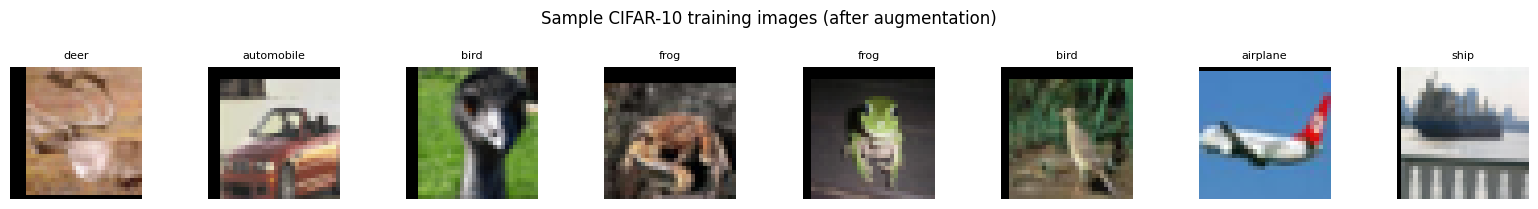

In [ ]:
# Quick sanity-check: visualise a few training samples
batch_images, batch_labels = next(iter(train_ds.take(1).as_numpy_iterator()))

# Un-normalise for display
show = batch_images[:8] * STD + MEAN
show = np.clip(show, 0, 1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, img, lbl in zip(axes, show, batch_labels[:8]):
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[lbl], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 training images (after augmentation)", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Model — FlexibleAlexNet (Flax Linen)

Each convolutional block follows: `Conv → BatchNorm → ReLU [→ MaxPool]`

`FlexibleAlexNet` takes four structural arguments:
- **`conv_features`** — tuple of 5 ints, one filter count per conv block
- **`kernel_sizes`** — tuple of 5 ints, one kernel size per conv block
- **`dense_widths`** — tuple of variable length; each entry adds one FC layer
- **`dropout_rate`** — applied after every FC layer

The pool schedule (after blocks 0, 1, 4) is intentionally fixed — it controls
the spatial resolution schedule and changing it would collapse feature maps
on 32×32 CIFAR-10 input. Everything else is free to vary.

The `train_step` and `eval_step` functions are model-agnostic — they work
identically regardless of which config `FlexibleAlexNet` is instantiated with.


In [ ]:
from typing import Sequence

# ── Preset conv filter configs ───────────────────────────────────────────────
#
# Rather than searching per-block filter counts independently (5 dims × many
# choices = huge combinatorial space), we use three curated presets that
# represent qualitatively different capacity levels.  Optuna picks among these
# as a single categorical HP.  This keeps the search tractable (15 trials)
# while still exploring meaningful architectural variation.
#
CONV_WIDTHS = {
    #              F0   F1   F2   F3   F4
    "narrow":   ( 32,  96, 192, 128, 128),   # ~2.5M params (2-FC-1024 head)
    "standard": ( 64, 192, 384, 256, 256),   # ~8.5M  — original AlexNet config
    "wide":     ( 96, 256, 512, 384, 384),   # ~18M   — richer features, slower
}


class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU [ → MaxPool ]."""
    features   : int
    kernel_size: int  = 3
    pool       : bool = False

    @nn.compact
    def __call__(self, x, train: bool):
        x = nn.Conv(
            features    = self.features,
            kernel_size = (self.kernel_size, self.kernel_size),
            padding     = "SAME",
            use_bias    = False,
        )(x)
        x = nn.BatchNorm(use_running_average=not train)(x)
        x = nn.relu(x)
        if self.pool:
            x = nn.max_pool(x, window_shape=(3, 3), strides=(2, 2), padding="VALID")
        return x


class FlexibleAlexNet(nn.Module):
    """
    Parametric AlexNet for 32×32 CIFAR-10 input.

    Args:
        conv_features  : 5-tuple of ints  — filter count per conv block.
        kernel_sizes   : 5-tuple of ints  — kernel size per conv block.
        dense_widths   : variable-length tuple — width of each FC layer.
                         len=1 → single FC; len=2 → two FCs; len=3 → three FCs.
        dropout_rate   : dropout probability applied after every FC layer.
        num_classes    : output logits dimension.

    Spatial progression (pool schedule is FIXED regardless of other HPs):
      32 → (pool0) 15 → (pool1) 7 → 7 → 7 → (pool4) 3 → flatten

    Why fix the pool schedule?
      Pooling halves spatial size.  With 32×32 input, a third early pool would
      collapse to 3×3 before the deeper conv blocks, destroying spatial structure.
      The schedule {0,1,4} mirrors the original and keeps feature maps viable.
    """
    num_classes  : int
    conv_features: Sequence[int]   # length must be 5
    kernel_sizes : Sequence[int]   # length must be 5
    dense_widths : Sequence[int]   # variable length — each entry = one FC layer
    dropout_rate : float = 0.5

    # Blocks that are followed by max-pooling (0-indexed)
    # Kept as a class-level constant — not a hyperparameter.
    _POOL_AFTER  = frozenset({0, 1, 4})

    @nn.compact
    def __call__(self, x, train: bool = True):
        # ── Convolutional backbone ─────────────────────────────────────────
        for i, (feats, ks) in enumerate(
            zip(self.conv_features, self.kernel_sizes)
        ):
            x = ConvBlock(
                features    = feats,
                kernel_size = ks,
                pool        = (i in self._POOL_AFTER),
            )(x, train)

        # ── Flatten ────────────────────────────────────────────────────────
        x = x.reshape((x.shape[0], -1))

        # ── Classifier head (variable depth) ──────────────────────────────
        #
        # Each entry in dense_widths adds one FC → ReLU → Dropout block.
        # The final classification layer (no activation, no dropout) is
        # always appended regardless of dense_widths length.
        for width in self.dense_widths:
            x = nn.Dense(width)(x)
            x = nn.relu(x)
            x = nn.Dropout(
                rate          = self.dropout_rate,
                deterministic = not train,
            )(x)

        x = nn.Dense(self.num_classes)(x)   # logits
        return x


In [ ]:
# ── Instantiate with the 'standard' config (≡ original AlexNet) ─────────────
model = FlexibleAlexNet(
    num_classes   = NUM_CLASSES,
    conv_features = CONV_WIDTHS["standard"],
    kernel_sizes  = (3, 3, 3, 3, 3),
    dense_widths  = (2048, 2048),
    dropout_rate  = 0.5,
)

key, init_key = jax.random.split(key)
dummy      = jnp.ones((1, IMAGE_SIZE, IMAGE_SIZE, 3))
variables  = model.init(init_key, dummy, train=False)

n_params = sum(
    np.prod(p.shape)
    for p in jax.tree_util.tree_leaves(variables["params"])
)
print(f"Config         : standard  |  kernel=3  |  dense=(2048, 2048)")
print(f"Trainable params: {n_params:,}")

logits, _ = model.apply(variables, dummy, train=False, mutable=["batch_stats"])
print(f"Output shape   : {logits.shape}  (batch=1, classes={NUM_CLASSES})")

# ── Quick comparison across configs ──────────────────────────────────────────
print("\nParam count survey across FlexibleAlexNet configs:")
print(f"{'conv_width':<12}  {'kernel':<8}  {'dense_widths':<20}  {'params':>10}")
print("-" * 58)
for cw in ["narrow", "standard", "wide"]:
    for ks in [3, 5]:
        for dw in [(1024,), (2048, 2048), (1024, 1024, 512)]:
            m = FlexibleAlexNet(
                num_classes   = NUM_CLASSES,
                conv_features = CONV_WIDTHS[cw],
                kernel_sizes  = (ks,)*5,
                dense_widths  = dw,
                dropout_rate  = 0.5,
            )
            v  = m.init(init_key, dummy, train=False)
            np_ = sum(np.prod(p.shape) for p in jax.tree_util.tree_leaves(v["params"]))
            print(f"{cw:<12}  {ks}×{ks:<6}  {str(dw):<20}  {np_:>10,}")


Config         : standard  |  kernel=3  |  dense=(2048, 2048)
Trainable params: 11,190,218
Output shape   : (1, 10)  (batch=1, classes=10)

Param count survey across FlexibleAlexNet configs:
conv_width    kernel    dense_widths              params
----------------------------------------------------------
narrow        3×3       (1024,)                1,755,114
narrow        3×3       (2048, 2048)           7,142,378
narrow        3×3       (1024, 1024, 512)      3,324,394
narrow        5×5       (1024,)                2,756,074
narrow        5×5       (2048, 2048)           8,143,338
narrow        5×5       (1024, 1024, 512)      4,325,354
standard      3×3       (1024,)                4,623,306
standard      3×3       (2048, 2048)          11,190,218
standard      3×3       (1024, 1024, 512)      6,192,586
standard      5×5       (1024,)                8,624,074
standard      5×5       (2048, 2048)          15,190,986
standard      5×5       (1024, 1024, 512)     10,193,354
wide     

## 5 · Training state, loss, and metrics

In [ ]:
# ── Hyper-parameters (vanilla baseline — 'standard' FlexibleAlexNet) ────────
NUM_EPOCHS    = 60
WARMUP_EPOCHS = 5
BASE_LR       = 1e-3
WEIGHT_DECAY  = 1e-4

steps_per_epoch = len(train_ds)
total_steps     = NUM_EPOCHS * steps_per_epoch
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

schedule = optax.warmup_cosine_decay_schedule(
    init_value   = 0.0,
    peak_value   = BASE_LR,
    warmup_steps = warmup_steps,
    decay_steps  = total_steps,
    end_value    = 1e-6,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=schedule, weight_decay=WEIGHT_DECAY),
)


class TrainState(train_state.TrainState):
    batch_stats: Any


def create_train_state(rng, model, optimizer, image_size):
    init_key, dropout_key = jax.random.split(rng)
    dummy = jnp.ones((1, image_size, image_size, 3))
    variables = model.init(
        {"params": init_key, "dropout": dropout_key},
        dummy, train=True,
    )
    return TrainState.create(
        apply_fn    = model.apply,
        params      = variables["params"],
        tx          = optimizer,
        batch_stats = variables["batch_stats"],
    )


# Vanilla baseline uses the same config as the original AlexNet
model = FlexibleAlexNet(
    num_classes   = NUM_CLASSES,
    conv_features = CONV_WIDTHS["standard"],
    kernel_sizes  = (3, 3, 3, 3, 3),
    dense_widths  = (2048, 2048),
    dropout_rate  = 0.5,
)

key, state_key = jax.random.split(key)
state = create_train_state(state_key, model, optimizer, IMAGE_SIZE)
print("TrainState created (vanilla FlexibleAlexNet — standard config).")


TrainState created (vanilla FlexibleAlexNet — standard config).


## 6 · JIT-compiled train / eval steps

In [ ]:
@jax.jit
def train_step(state, images, labels, dropout_rng):
    """
    Single gradient update step.
    Returns updated state + dict of metrics.
    """
    def loss_fn(params):
        logits, updates = state.apply_fn(
            {"params": params, "batch_stats": state.batch_stats},
            images,
            train       = True,
            rngs        = {"dropout": dropout_rng},
            mutable     = ["batch_stats"],
        )
        one_hot = jax.nn.one_hot(labels, NUM_CLASSES)
        loss = jnp.mean(optax.softmax_cross_entropy(logits, one_hot))
        return loss, (logits, updates)

    (loss, (logits, updates)), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)

    state = state.apply_gradients(
        grads       = grads,
        batch_stats = updates["batch_stats"],
    )

    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return state, {"loss": loss, "accuracy": accuracy}


@jax.jit
def eval_step(state, images, labels):
    """
    Forward pass with running BN statistics (no gradient, no dropout).
    """
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        images,
        train = False,
    )
    one_hot  = jax.nn.one_hot(labels, NUM_CLASSES)
    loss     = jnp.mean(optax.softmax_cross_entropy(logits, one_hot))
    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return {"loss": loss, "accuracy": accuracy}

## 7 · Training loop

In [ ]:
import time

history = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  [],
    "epoch_time": [],   # ← new: wall-clock seconds per epoch
}


def evaluate(state, dataset):
    """Run eval_step over the entire dataset and return averaged metrics."""
    metrics = {"loss": [], "accuracy": []}
    for images, labels in dataset.as_numpy_iterator():
        m = eval_step(state, images, labels)
        metrics["loss"].append(float(m["loss"]))
        metrics["accuracy"].append(float(m["accuracy"]))
    return {k: np.mean(v) for k, v in metrics.items()}


print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  "
      f"{'Test Loss':>10}  {'Test Acc':>10}  {'Time(s)':>8}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.perf_counter()          # ← start timer

    # ── Training ──────────────────────────────────────────────────────
    train_metrics = {"loss": [], "accuracy": []}

    for images, labels in train_ds.as_numpy_iterator():
        key, dropout_key = jax.random.split(key)
        state, m = train_step(state, images, labels, dropout_key)
        train_metrics["loss"].append(float(m["loss"]))
        train_metrics["accuracy"].append(float(m["accuracy"]))

    train_loss = np.mean(train_metrics["loss"])
    train_acc  = np.mean(train_metrics["accuracy"])

    # ── Evaluation ────────────────────────────────────────────────────
    test_m = evaluate(state, test_ds)

    epoch_time = time.perf_counter() - epoch_start  # ← stop timer

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_m["loss"])
    history["test_acc"].append(test_m["accuracy"])
    history["epoch_time"].append(epoch_time)        # ← record it

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"{epoch:>6}  "
            f"{train_loss:>10.4f}  {train_acc*100:>9.2f}%  "
            f"{test_m['loss']:>10.4f}  {test_m['accuracy']*100:>9.2f}%  "
            f"{epoch_time:>7.1f}s"
        )

avg_epoch_time = np.mean(history["epoch_time"])
print(f"\nFinal test accuracy : {history['test_acc'][-1]*100:.2f}%")
print(f"Avg time / epoch    : {avg_epoch_time:.1f}s  "
      f"(total {avg_epoch_time*NUM_EPOCHS/60:.1f} min)")


 Epoch  Train Loss   Train Acc   Test Loss    Test Acc   Time(s)
------------------------------------------------------------------------
     1      1.8492      34.18%      1.5614      44.43%     20.6s
     5      0.8562      71.34%      0.8934      70.97%     11.0s
    10      0.4582      84.71%      0.6774      78.70%     13.0s
    15      0.1972      93.56%      0.7667      80.45%     12.2s
    20      0.0890      97.18%      1.0255      81.22%     12.3s
    25      0.0463      98.56%      1.0068      82.84%     12.4s
    30      0.0262      99.21%      1.2002      84.07%     12.5s
    35      0.0123      99.61%      1.2550      84.60%     12.4s
    40      0.0072      99.82%      1.4605      85.13%     12.4s
    45      0.0017      99.95%      1.6083      85.70%     12.4s
    50      0.0001     100.00%      1.6490      86.17%     12.5s
    55      0.0000     100.00%      1.7109      86.32%     12.5s
    60      0.0001     100.00%      1.7183      86.37%     12.4s

Final test accur

---
## 7b · Hyperparameter Tuning with Optuna — Architecture + Training Joint Search

This is **joint architecture and training HP search** — Optuna simultaneously
decides the model's structure *and* how to train it.  This is qualitatively
more powerful than tuning training HPs alone, because architecture choices
(capacity, receptive field, head depth) interact strongly with the optimal
learning rate and regularisation.

### Full search space

**Architecture HPs** (new — control the model itself):

| HP | Type | Choices | What it controls |
|---|---|---|---|
| `conv_width` | categorical | narrow / standard / wide | Filter counts in all 5 conv blocks |
| `kernel_size` | categorical | 3, 5 | Receptive field size (same for all blocks) |
| `num_dense_layers` | int | 1 – 3 | Depth of the FC classifier head |
| `dense_width` | categorical | 512, 1024, 2048 | Width of every FC layer in the head |

**Training HPs** (carried over from before):

| HP | Type | Range |
|---|---|---|
| `base_lr` | float log-uniform | [1e-4, 1e-2] |
| `weight_decay` | float log-uniform | [1e-5, 1e-3] |
| `dropout_rate` | float uniform | [0.2, 0.6] |
| `warmup_epochs` | categorical | {2, 3, 5, 8} |

### Why preset conv width rather than per-block filter counts?

Searching 5 independent filter counts (each from ~8 choices) would create
a ~8⁵ = 32 768 point combinatorial space — vastly too large for 15 trials.
The three presets (narrow / standard / wide) instead parameterise a
1D capacity axis that Optuna can efficiently distinguish within budget:
```
narrow   → (32,  96,  192, 128, 128)   ~2.5M params
standard → (64,  192, 384, 256, 256)   ~8.5M params  ← original AlexNet
wide     → (96,  256, 512, 384, 384)   ~18M  params
```

### Parameter budget guard

Wide conv + 5×5 kernels + 3 dense layers of 2048 can push >25M params — far
too slow for a 15-epoch trial on a T4.  The objective function checks the
**total parameter count** before training starts and prunes any trial that
exceeds `MAX_TRIAL_PARAMS = 20_000_000`.  This keeps trial time predictable.

### Colab T4 quota estimate
```
Narrow  config: ~20s/epoch  →  15 trials × 15 ep ≈  75 min worst-case
Standard config: ~25s/epoch  →  15 trials × 15 ep ≈  94 min worst-case
Wide    config: ~35s/epoch  →  (usually pruned by param guard or MedianPruner)
With pruning (typical):                            ≈  55–70 min
Final 60-epoch run (best config):                  ≈  20–35 min
──────────────────────────────────────────────────────────────────
Total:                                             ≈  75–105 min
```


In [ ]:
# Optuna should already be installed from cell 1.
# This cell just confirms it and sets the logging level.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-step spam
print(f"Optuna version: {optuna.__version__}")


Optuna version: 4.8.0


In [ ]:
import time

# ── Optuna budget ────────────────────────────────────────────────────────────
OPTUNA_TRIALS    = 15          # total trials
OPTUNA_EPOCHS    = 15          # epochs per trial
MAX_TRIAL_PARAMS = 20_000_000  # prune architectures with more than this many params


def build_optimizer_for_trial(trial_lr, trial_wd, n_epochs):
    """Build an optax optimizer for a given LR, WD, and epoch count."""
    n_steps  = n_epochs * len(train_ds)
    wu_steps = 2 * len(train_ds)       # fixed 2-epoch warmup inside trials
    schedule = optax.warmup_cosine_decay_schedule(
        init_value   = 0.0,
        peak_value   = trial_lr,
        warmup_steps = wu_steps,
        decay_steps  = n_steps,
        end_value    = 1e-6,
    )
    return optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(learning_rate=schedule, weight_decay=trial_wd),
    )


def objective(trial):
    """
    Joint architecture + training HP objective for FlexibleAlexNet.

    Search dimensions:
      Architecture: conv_width, kernel_size, num_dense_layers, dense_width
      Training    : base_lr, weight_decay, dropout_rate, warmup_epochs

    Two pruning mechanisms:
      (a) Parameter budget guard — prune before training if arch > MAX_TRIAL_PARAMS
      (b) Optuna MedianPruner   — prune mid-training if val-acc falls below median
    """
    # ── 1. Suggest architecture hyperparameters ───────────────────────────
    conv_width       = trial.suggest_categorical("conv_width",       ["narrow", "standard", "wide"])
    kernel_size      = trial.suggest_categorical("kernel_size",      [3, 5])
    num_dense_layers = trial.suggest_int(        "num_dense_layers", 1, 3)
    dense_width      = trial.suggest_categorical("dense_width",      [512, 1024, 2048])

    # ── 2. Suggest training hyperparameters ──────────────────────────────
    trial_lr      = trial.suggest_float("base_lr",       1e-4, 1e-2, log=True)
    trial_wd      = trial.suggest_float("weight_decay",  1e-5, 1e-3, log=True)
    trial_dropout = trial.suggest_float("dropout_rate",  0.2,  0.6)
    trial_warmup  = trial.suggest_categorical("warmup_epochs", [2, 3, 5, 8])

    # ── 3. Construct the model config ─────────────────────────────────────
    conv_features = CONV_WIDTHS[conv_width]
    kernel_sizes  = (kernel_size,) * 5
    dense_widths  = (dense_width,) * num_dense_layers

    trial_model = FlexibleAlexNet(
        num_classes   = NUM_CLASSES,
        conv_features = conv_features,
        kernel_sizes  = kernel_sizes,
        dense_widths  = dense_widths,
        dropout_rate  = trial_dropout,
    )

    # ── 4. Parameter budget guard (prune before any training) ─────────────
    #
    # We count params on a cheap dummy forward pass — no GPU memory allocated.
    # This catches e.g. wide + 5×5 + 3×2048 FC which would be >25M and very
    # slow on a T4.  We raise TrialPruned immediately so the trial costs < 1s.
    t_key = jax.random.PRNGKey(trial.number)
    t_key, ik, dk = *jax.random.split(t_key, 3),
    dummy_x = jnp.ones((1, IMAGE_SIZE, IMAGE_SIZE, 3))
    v = trial_model.init({"params": ik, "dropout": dk}, dummy_x, train=False)
    n_params = sum(np.prod(p.shape) for p in jax.tree_util.tree_leaves(v["params"]))

    if n_params > MAX_TRIAL_PARAMS:
        print(f"  Trial {trial.number:>2} PRUNED (param budget)  "
              f"{conv_width}/{kernel_size}×{kernel_size}/{num_dense_layers}FC-{dense_width}  "
              f"→ {n_params/1e6:.1f}M params > {MAX_TRIAL_PARAMS/1e6:.0f}M limit")
        raise optuna.exceptions.TrialPruned()

    # ── 5. Build optimizer and training state ─────────────────────────────
    trial_opt = build_optimizer_for_trial(trial_lr, trial_wd, OPTUNA_EPOCHS)
    t_key, sk = jax.random.split(t_key)
    t_state   = create_train_state(sk, trial_model, trial_opt, IMAGE_SIZE)

    best_val_acc = 0.0
    trial_start  = time.perf_counter()

    # ── 6. Short training loop with MedianPruner ──────────────────────────
    for epoch in range(1, OPTUNA_EPOCHS + 1):
        for images, labels in train_ds.as_numpy_iterator():
            t_key, dk = jax.random.split(t_key)
            t_state, _ = train_step(t_state, images, labels, dk)

        val_m    = evaluate(t_state, test_ds)
        val_acc  = float(val_m["accuracy"])
        best_val_acc = max(best_val_acc, val_acc)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            elapsed = time.perf_counter() - trial_start
            print(f"  Trial {trial.number:>2} PRUNED (median)  "
                  f"{conv_width}/{kernel_size}×{kernel_size}/{num_dense_layers}FC-{dense_width}  "
                  f"ep {epoch:>2}  val {val_acc*100:.1f}%  [{elapsed:.0f}s]")
            raise optuna.exceptions.TrialPruned()

    elapsed = time.perf_counter() - trial_start
    print(
        f"  Trial {trial.number:>2}  "
        f"{conv_width}/{kernel_size}×{kernel_size}/{num_dense_layers}FC-{dense_width}  "
        f"{n_params/1e6:.1f}M params  "
        f"lr={trial_lr:.1e}  wd={trial_wd:.1e}  dr={trial_dropout:.2f}  wu={trial_warmup}ep  "
        f"→ val {best_val_acc*100:.2f}%  [{elapsed:.0f}s]"
    )
    return best_val_acc


In [ ]:
# ── Run the study ────────────────────────────────────────────────────────────
# MedianPruner: after the first 3 epochs (n_startup_trials warmup),
# prune any trial whose val-acc falls below the median at that epoch.
pruner = optuna.pruners.MedianPruner(
    n_startup_trials  = 3,   # don't prune until we have 3 reference trials
    n_warmup_steps    = 3,   # don't prune before epoch 3 within a trial
    interval_steps    = 1,
)

study = optuna.create_study(
    direction = "maximize",   # we want to maximise validation accuracy
    sampler   = optuna.samplers.TPESampler(seed=SEED),
    pruner    = pruner,
)

print(f"Starting Optuna search: {OPTUNA_TRIALS} trials × up to {OPTUNA_EPOCHS} epochs each")
print(f"Estimated worst-case time: "
      f"{OPTUNA_TRIALS * OPTUNA_EPOCHS * 25 / 60:.0f} min  (pruning will reduce this)")
print("-" * 78)

study_start = time.perf_counter()
study.optimize(objective, n_trials=OPTUNA_TRIALS)
study_elapsed = (time.perf_counter() - study_start) / 60

print("-" * 78)
print(f"\nSearch complete in {study_elapsed:.1f} min")
print(f"Trials completed : {len(study.trials)}")
print(f"Trials pruned    : {sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}")


Starting Optuna search: 15 trials × up to 15 epochs each
Estimated worst-case time: 94 min  (pruning will reduce this)
------------------------------------------------------------------------------
  Trial  0  standard/3×3/2FC-2048  11.2M params  lr=5.8e-04  wd=3.8e-04  dr=0.41  wu=3ep  → val 84.85%  [191s]
  Trial  1  standard/5×5/3FC-1024  10.7M params  lr=1.9e-03  wd=1.9e-05  dr=0.58  wu=8ep  → val 84.13%  [401s]
  Trial  2  standard/3×3/2FC-512  3.7M params  lr=7.5e-04  wd=2.5e-04  dr=0.22  wu=3ep  → val 85.53%  [174s]
  Trial  3 PRUNED (median)  wide/5×5/1FC-2048  ep  5  val 66.0%  [266s]
  Trial  4 PRUNED (median)  wide/5×5/1FC-2048  ep  5  val 65.5%  [246s]
  Trial  5 PRUNED (median)  standard/3×3/1FC-2048  ep 10  val 82.4%  [122s]
  Trial  6 PRUNED (median)  wide/5×5/1FC-1024  ep  6  val 69.1%  [290s]
  Trial  7 PRUNED (median)  wide/5×5/2FC-512  ep  5  val 69.5%  [241s]
  Trial  8 PRUNED (median)  narrow/3×3/1FC-1024  ep 10  val 79.9%  [50s]
  Trial  9 PRUNED (median)  narrow/

Best trial found by Optuna:
  Trial #       : 2
  Val accuracy  : 85.53%
  Architecture:
    conv_width       = standard  (64, 192, 384, 256, 256)
    kernel_size      = 3×3
    num_dense_layers = 2
    dense_width      = 512
  Training:
    base_lr          = 7.48e-04
    weight_decay     = 2.48e-04
    dropout_rate     = 0.224
    warmup_epochs    = 3


/tmp/ipykernel_635/2223628664.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(box_data, patch_artist=True, labels=box_labels)


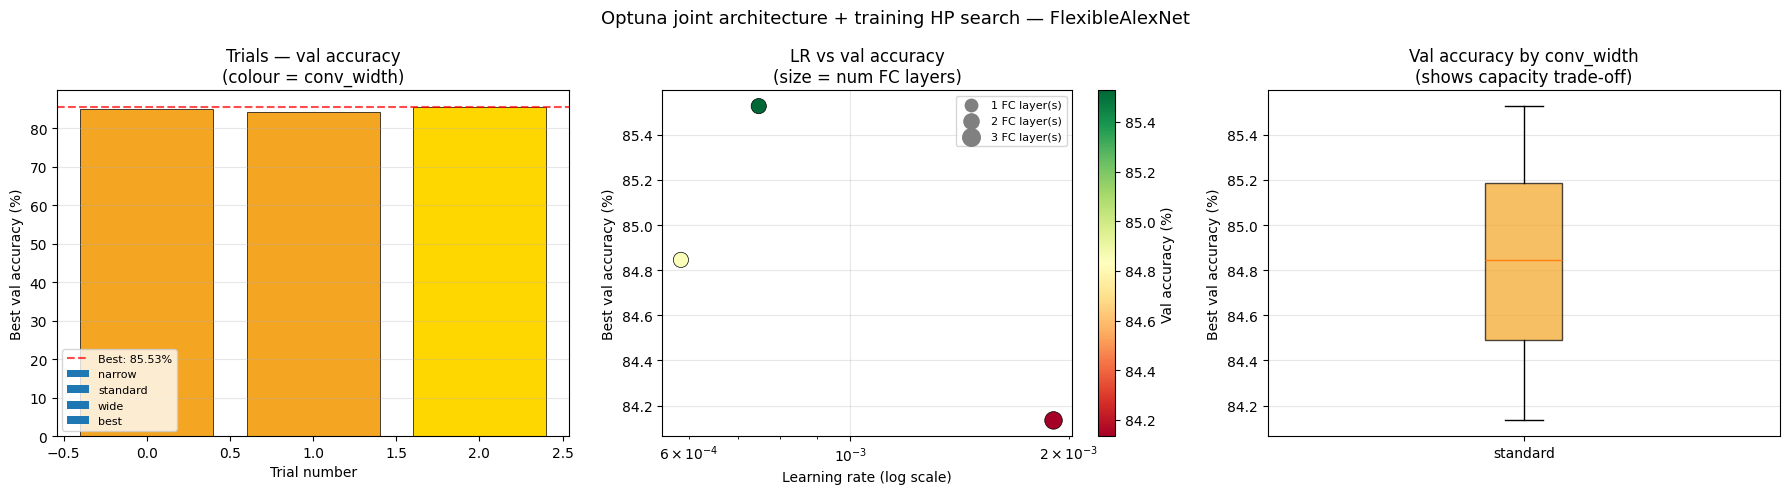

In [ ]:
# ── Best trial summary ───────────────────────────────────────────────────────
best = study.best_trial
print("Best trial found by Optuna:")
print(f"  Trial #       : {best.number}")
print(f"  Val accuracy  : {best.value*100:.2f}%")
print(f"  Architecture:")
print(f"    conv_width       = {best.params['conv_width']}  "
      f"{CONV_WIDTHS[best.params['conv_width']]}")
print(f"    kernel_size      = {best.params['kernel_size']}×{best.params['kernel_size']}")
print(f"    num_dense_layers = {best.params['num_dense_layers']}")
print(f"    dense_width      = {best.params['dense_width']}")
print(f"  Training:")
print(f"    base_lr          = {best.params['base_lr']:.2e}")
print(f"    weight_decay     = {best.params['weight_decay']:.2e}")
print(f"    dropout_rate     = {best.params['dropout_rate']:.3f}")
print(f"    warmup_epochs    = {best.params['warmup_epochs']}")

completed = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE
]

trial_nums   = [t.number              for t in completed]
trial_accs   = [t.value * 100         for t in completed]
trial_lrs    = [t.params["base_lr"]   for t in completed]
trial_widths = [t.params["conv_width"] for t in completed]
trial_nfc    = [t.params["num_dense_layers"] for t in completed]

width_color  = {"narrow": "#4e9af1", "standard": "#f4a522", "wide": "#e05c5c"}
bar_colors   = [width_color[w] for w in trial_widths]
bar_colors[trial_accs.index(max(trial_accs))] = "gold"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: val accuracy per trial, coloured by conv_width ──────────────────
axes[0].bar(trial_nums, trial_accs, color=bar_colors, edgecolor="black", linewidth=0.5)
for label, color in width_color.items():
    axes[0].bar([], [], color=color, label=label)   # legend proxy
axes[0].bar([], [], color="gold", label="best")
axes[0].axhline(max(trial_accs), color="red", linestyle="--", alpha=0.7,
                label=f"Best: {max(trial_accs):.2f}%")
axes[0].set_xlabel("Trial number")
axes[0].set_ylabel("Best val accuracy (%)")
axes[0].set_title("Trials — val accuracy\n(colour = conv_width)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# ── Panel 2: LR vs val accuracy, marker size = num_dense_layers ──────────────
sizes = [40 + 40 * n for n in trial_nfc]
sc = axes[1].scatter(trial_lrs, trial_accs,
                     c=trial_accs, cmap="RdYlGn", s=sizes,
                     edgecolors="black", linewidth=0.5,
                     vmin=min(trial_accs), vmax=max(trial_accs))
plt.colorbar(sc, ax=axes[1], label="Val accuracy (%)")
for n in [1, 2, 3]:
    axes[1].scatter([], [], s=40+40*n, c="grey", label=f"{n} FC layer(s)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Learning rate (log scale)")
axes[1].set_ylabel("Best val accuracy (%)")
axes[1].set_title("LR vs val accuracy\n(size = num FC layers)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ── Panel 3: val accuracy grouped by conv_width ───────────────────────────────
import collections
grouped = collections.defaultdict(list)
for t in completed:
    grouped[t.params["conv_width"]].append(t.value * 100)

box_data   = [grouped[k] for k in ["narrow", "standard", "wide"] if grouped[k]]
box_labels = [k          for k in ["narrow", "standard", "wide"] if grouped[k]]
bp = axes[2].boxplot(box_data, patch_artist=True, labels=box_labels)
for patch, label in zip(bp["boxes"], box_labels):
    patch.set_facecolor(width_color[label])
    patch.set_alpha(0.7)
axes[2].set_ylabel("Best val accuracy (%)")
axes[2].set_title("Val accuracy by conv_width\n(shows capacity trade-off)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Optuna joint architecture + training HP search — FlexibleAlexNet", fontsize=13)
plt.tight_layout()
plt.show()


### 7c · Full 60-epoch training with best FlexibleAlexNet config

Optuna found the best joint (architecture, training) configuration.
We now reconstruct `FlexibleAlexNet` with exactly those parameters and run
the real 60-epoch training.  `state` and `history` are overwritten — all
downstream cells use this tuned model.


In [ ]:
# ── Reconstruct best FlexibleAlexNet from Optuna results ─────────────────────
BEST_CONV_WIDTH       = best.params["conv_width"]
BEST_KERNEL_SIZE      = best.params["kernel_size"]
BEST_NUM_DENSE        = best.params["num_dense_layers"]
BEST_DENSE_WIDTH      = best.params["dense_width"]
BEST_LR               = best.params["base_lr"]
BEST_WD               = best.params["weight_decay"]
BEST_DROPOUT          = best.params["dropout_rate"]
BEST_WARMUP           = best.params["warmup_epochs"]

best_conv_features = CONV_WIDTHS[BEST_CONV_WIDTH]
best_kernel_sizes  = (BEST_KERNEL_SIZE,) * 5
best_dense_widths  = (BEST_DENSE_WIDTH,) * BEST_NUM_DENSE

print("Full 60-epoch run — best FlexibleAlexNet config:")
print(f"  conv_width       = {BEST_CONV_WIDTH}  {best_conv_features}")
print(f"  kernel_size      = {BEST_KERNEL_SIZE}×{BEST_KERNEL_SIZE}")
print(f"  dense_widths     = {best_dense_widths}")
print(f"  dropout_rate     = {BEST_DROPOUT:.3f}")
print(f"  base_lr          = {BEST_LR:.2e}")
print(f"  weight_decay     = {BEST_WD:.2e}")
print(f"  warmup_epochs    = {BEST_WARMUP}")

best_model = FlexibleAlexNet(
    num_classes   = NUM_CLASSES,
    conv_features = best_conv_features,
    kernel_sizes  = best_kernel_sizes,
    dense_widths  = best_dense_widths,
    dropout_rate  = BEST_DROPOUT,
)

# Count params of the winning architecture
dummy_x = jnp.ones((1, IMAGE_SIZE, IMAGE_SIZE, 3))
key, ik, dk = *jax.random.split(jax.random.PRNGKey(SEED), 3),
v = best_model.init({"params": ik, "dropout": dk}, dummy_x, train=False)
n_best = sum(np.prod(p.shape) for p in jax.tree_util.tree_leaves(v["params"]))
print(f"  total params     = {n_best:,}  ({n_best/1e6:.2f}M)")
print()

# ── Build optimizer ───────────────────────────────────────────────────────────
best_schedule = optax.warmup_cosine_decay_schedule(
    init_value   = 0.0,
    peak_value   = BEST_LR,
    warmup_steps = BEST_WARMUP * len(train_ds),
    decay_steps  = NUM_EPOCHS  * len(train_ds),
    end_value    = 1e-6,
)
best_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=best_schedule, weight_decay=BEST_WD),
)

key = jax.random.PRNGKey(SEED)
key, best_state_key = jax.random.split(key)
state = create_train_state(best_state_key, best_model, best_optimizer, IMAGE_SIZE)

# ── Full training loop ────────────────────────────────────────────────────────
history = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  [],
    "epoch_time": [],
}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  "
      f"{'Test Loss':>10}  {'Test Acc':>10}  {'Time(s)':>8}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start   = time.perf_counter()
    train_metrics = {"loss": [], "accuracy": []}

    for images, labels in train_ds.as_numpy_iterator():
        key, dropout_key = jax.random.split(key)
        state, m = train_step(state, images, labels, dropout_key)
        train_metrics["loss"].append(float(m["loss"]))
        train_metrics["accuracy"].append(float(m["accuracy"]))

    train_loss = np.mean(train_metrics["loss"])
    train_acc  = np.mean(train_metrics["accuracy"])
    test_m     = evaluate(state, test_ds)
    epoch_time = time.perf_counter() - epoch_start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_m["loss"])
    history["test_acc"].append(test_m["accuracy"])
    history["epoch_time"].append(epoch_time)

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"{epoch:>6}  "
            f"{train_loss:>10.4f}  {train_acc*100:>9.2f}%  "
            f"{test_m['loss']:>10.4f}  {test_m['accuracy']*100:>9.2f}%  "
            f"{epoch_time:>7.1f}s"
        )

avg_epoch_time = np.mean(history["epoch_time"])
print(f"\nFinal test accuracy (FlexibleAlexNet tuned) : {history['test_acc'][-1]*100:.2f}%")
print(f"Avg time / epoch                            : {avg_epoch_time:.1f}s  "
      f"(total {avg_epoch_time*NUM_EPOCHS/60:.1f} min)")


Full 60-epoch run — best FlexibleAlexNet config:
  conv_width       = standard  (64, 192, 384, 256, 256)
  kernel_size      = 3×3
  dense_widths     = (512, 512)
  dropout_rate     = 0.224
  base_lr          = 7.48e-04
  weight_decay     = 2.48e-04
  warmup_epochs    = 3
  total params     = 3,700,682  (3.70M)

 Epoch  Train Loss   Train Acc   Test Loss    Test Acc   Time(s)
------------------------------------------------------------------------
     1      1.6659      39.34%      1.3028      52.51%     16.7s
     5      0.6903      76.00%      0.9735      67.77%     11.1s
    10      0.3419      88.30%      0.7097      79.01%     11.3s
    15      0.1566      94.73%      0.8939      79.95%     11.2s
    20      0.0781      97.32%      0.9454      82.48%     11.2s
    25      0.0460      98.52%      1.0499      83.52%     11.1s
    30      0.0232      99.24%      1.2876      82.88%     11.1s
    35      0.0123      99.61%      1.3858      83.97%     11.1s
    40      0.0050      99.84

## 8 · Training curves

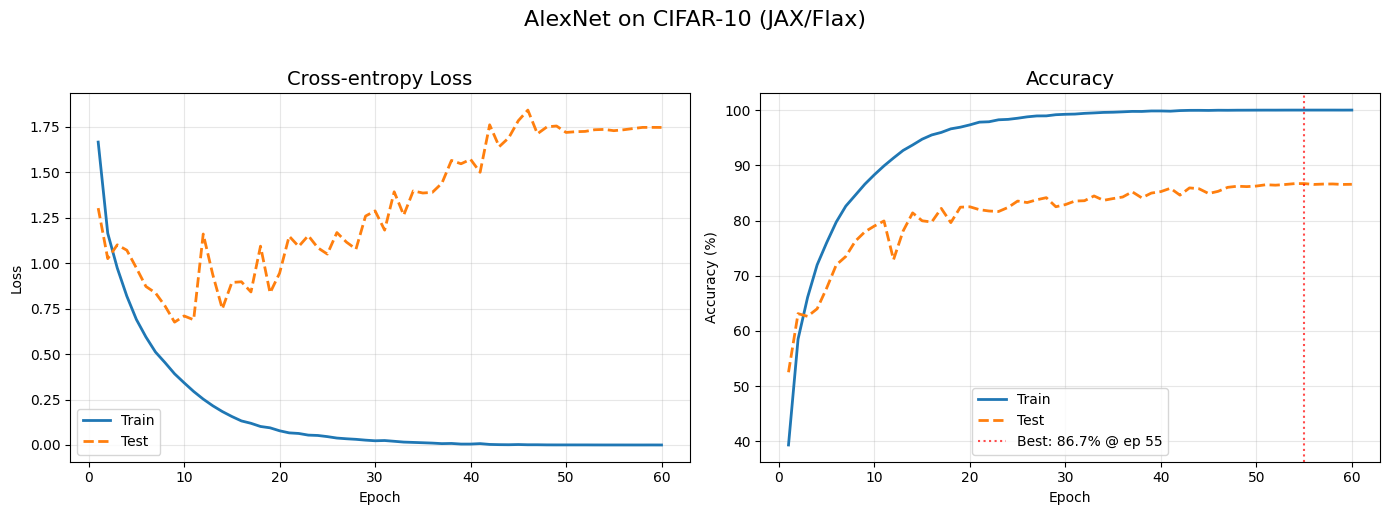

Best test accuracy : 86.69% (epoch 55)


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history["train_loss"], label="Train",  lw=2)
ax1.plot(epochs, history["test_loss"],  label="Test",   lw=2, linestyle="--")
ax1.set_title("Cross-entropy Loss", fontsize=14)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Train",  lw=2)
ax2.plot(epochs, [a * 100 for a in history["test_acc"]],  label="Test",   lw=2, linestyle="--")
ax2.set_title("Accuracy", fontsize=14)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

best_epoch = int(np.argmax(history["test_acc"])) + 1
best_acc   = max(history["test_acc"]) * 100
ax2.axvline(best_epoch, color="red", linestyle=":", alpha=0.7, label=f"Best: {best_acc:.1f}% @ ep {best_epoch}")
ax2.legend()

plt.suptitle("AlexNet on CIFAR-10 (JAX/Flax)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Best test accuracy : {best_acc:.2f}% (epoch {best_epoch})")

## 9 · Inference — per-class accuracy & confusion matrix

In [ ]:
all_preds  = []
all_labels = []

for images, labels in test_ds.as_numpy_iterator():
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        images,
        train=False,
    )
    all_preds.append(np.array(jnp.argmax(logits, axis=-1)))
    all_labels.append(labels)

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Per-class accuracy
print("Per-class accuracy:")
print("-" * 35)
for c in range(NUM_CLASSES):
    mask = all_labels == c
    acc  = np.mean(all_preds[mask] == all_labels[mask]) * 100
    print(f"  {CIFAR10_CLASSES[c]:<12} {acc:>6.2f}%")

Per-class accuracy:
-----------------------------------
  airplane      86.97%
  automobile    95.50%
  bird          79.94%
  cat           72.92%
  deer          86.90%
  dog           81.78%
  frog          91.27%
  horse         87.50%
  ship          93.09%
  truck         89.69%


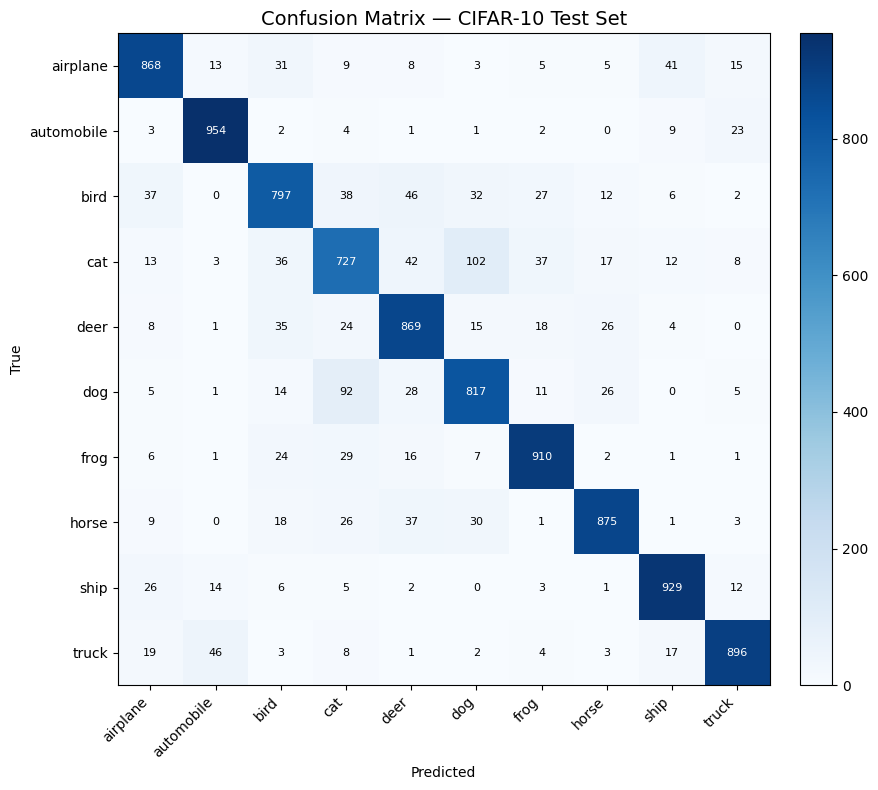

In [ ]:
# Confusion matrix
conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    conf[t, p] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — CIFAR-10 Test Set", fontsize=14)

# Annotate cells
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if conf[i, j] > conf.max() * 0.5 else "black"
        ax.text(j, i, str(conf[i, j]), ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.show()

## 10 · Visual predictions on test samples

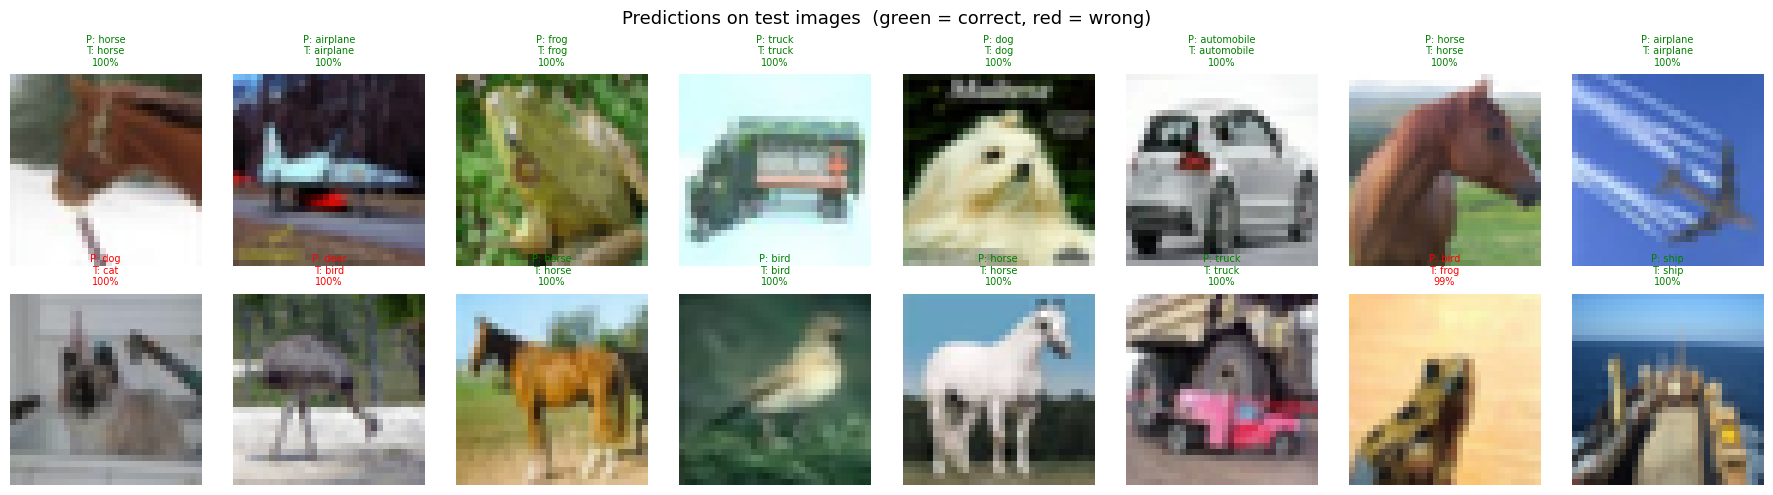

In [ ]:
# Grab one test batch
test_images, test_labels = next(iter(test_ds.take(1).as_numpy_iterator()))

logits = state.apply_fn(
    {"params": state.params, "batch_stats": state.batch_stats},
    test_images,
    train=False,
)
probs   = jax.nn.softmax(logits)
preds   = jnp.argmax(logits, axis=-1)
confs   = jnp.max(probs, axis=-1)

# Un-normalise for display
display_imgs = test_images[:16] * STD + MEAN
display_imgs = np.clip(display_imgs, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(display_imgs[idx])
    pred  = int(preds[idx])
    true  = int(test_labels[idx])
    conf  = float(confs[idx])
    color = "green" if pred == true else "red"
    ax.set_title(
        f"P: {CIFAR10_CLASSES[pred]}\nT: {CIFAR10_CLASSES[true]}\n{conf*100:.0f}%",
        fontsize=7, color=color
    )
    ax.axis("off")

plt.suptitle("Predictions on test images  (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## Notes & further reading

### Why fix the pool schedule in FlexibleAlexNet?
Pooling is a spatial operation — it halves the feature map dimensions.  On
32×32 CIFAR-10 input, the progression 32→15→7→3 leaves just 3×3 spatial
resolution for the final conv block, which is already tight.  Allowing Optuna
to move pools earlier would risk collapsing feature maps before the deeper
conv blocks see them.  The pool schedule is therefore a structural prior, not
a hyperparameter.

### Why preset conv_width presets rather than per-block filter counts?
Per-block search would require 5 independent HP dimensions each with 6–8
choices — an ~8⁵ space that needs hundreds of trials for TPE to navigate.
The three presets collapse this to a single categorical, preserving the
most important variation (capacity) while keeping the search tractable.
This is an instance of **search space design**: good HPO is as much about
what you *don't* search as what you do.

### Why does kernel_size matter on CIFAR-10?
CIFAR-10 images are 32×32 — small objects, tight spatial budget.  A 5×5
kernel covers a 5×5 receptive field at the first layer, which is roughly
15% of the image width.  This can be beneficial (captures more context per
layer) or harmful (too aggressive a receptive field for fine textures).
Letting Optuna decide rather than assuming 3×3 is correct is worthwhile.

### What joint search enables that independent search misses
A wider network (more filters) may tolerate or even require a lower learning
rate to converge stably — wider models have larger gradient norms.  A deeper
head may need stronger dropout.  These interactions mean the optimal training
HP *depends on* the architecture HP.  Searching them independently would find
the best training HPs for a fixed architecture, missing the global optimum.

### Typical CIFAR-10 numbers
| Model | Test Acc |
|---|---|
| FlexibleAlexNet (narrow, tuned) | ~87–89% |
| FlexibleAlexNet (standard, tuned) | ~89–91% |
| VGG-16 | ~93% |
| ResNet-20 | ~92% |
| WideResNet-28-10 | ~96% |

### JAX / Flax patterns used here
- `Sequence[int]` fields in `nn.Module` — Flax handles variable-length tuples
  as module fields correctly, enabling dynamic head depth at init time
- `frozenset` as a class attribute — safe to use in `@nn.compact` because it
  is a pure Python constant, not a JAX array
- `jax.value_and_grad` — compute loss and gradients in one pass
- `@jax.jit` — traces once per unique input shape; since all FlexibleAlexNet
  variants produce the same batch shape, JIT compilation is reused across trials
